# Notebook 03 — Real-Data Evaluation on S&P 500

**Kernel:** deep hedging environment (Python 3.11+, torch)

**Prerequisites:** 
- `01_gad_calibration.ipynb` — data in `data/sp500_prices/` and `data/gad_params_fix.json`
- `02_gad_training.ipynb` — models in `results/real_data/`

Steps:
1. Build real test windows from S&P 500 constituent prices
2. Load trained networks
3. Compute hedging errors and entropic risk for all methods
4. Primary results table
5. Sector breakdown
6. Realised-volatility quintile breakdown
7. Data-efficiency: entropic risk vs. training sample size N
8. BS delta analytical baseline

In [1]:
import sys
import json
import time
from functools import partial
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "real_data"

def _auto_device() -> torch.device:
    if torch.cuda.is_available():           return torch.device("cuda")
    if torch.backends.mps.is_available():   return torch.device("mps")
    return torch.device("cpu")

DEVICE = _auto_device()
print(f"Device: {DEVICE}")

Device: mps


In [2]:
from src.gad_simulator import GADParams, GADSimulator
from src.hedging.hedge_network import HedgeNet
from src.hedging.loss import EntropicOCELoss
from src.hedging.gad_adv_trainer import (
    gad_linf_attack,
    train_adv_gad,
    compute_errors,
)
from src.hedging.theoretical import bs_delta
from src.real_data.sp500_loader import build_test_windows, compute_entropic_risk

## 1. Load GAD Params & Build Real Test Windows

In [3]:
with open(DATA_DIR / "gad_params_fix.json") as f:
    p_dict = json.load(f)

N_STEPS  = 30
T        = 30 / 252
S0       = 10.0
K        = 10.0
LAMB     = 1.0
SIGMA_EFF = p_dict["a0"] + p_dict["a1"] * S0

loss_fn = EntropicOCELoss(K=K, sigma=SIGMA_EFF, T=T, lamb=LAMB, X_max=True)
print(f"σ_eff = {SIGMA_EFF:.4f}")

σ_eff = 0.9866


In [4]:
print("Building real test windows …")
t0 = time.perf_counter()
S_real, ticker_labels = build_test_windows(
    DATA_DIR / "sp500_prices",
    T=N_STEPS,
    S0_norm=S0,
)
print(f"  Real windows: {S_real.shape}  ({time.perf_counter()-t0:.1f}s)")
print(f"  Unique tickers in test set: {len(set(ticker_labels))}")

Building real test windows …
  Real windows: torch.Size([461513, 31])  (3.3s)
  Unique tickers in test set: 498


## 2. Load Trained Networks

In [6]:
def load_net(name: str) -> HedgeNet:
    net = HedgeNet(N=N_STEPS, width=20)
    net.load_state_dict(torch.load(RESULTS_DIR / f"{name}_net.pt", map_location="cpu", weights_only=True))
    return net

net_clean = load_net("clean")
net_adv   = load_net("adv")
net_bs    = load_net("bs_deep")
print("Loaded: clean, adv, bs_deep")

Loaded: clean, adv, bs_deep


## 3. Compute Hedging Errors on Real Paths

In [7]:
print("Computing hedging errors …")
errors_clean = compute_errors(net_clean, S_real, K, DEVICE)
errors_adv   = compute_errors(net_adv,   S_real, K, DEVICE)
errors_bs_nn = compute_errors(net_bs,    S_real, K, DEVICE)
print(f"  {len(errors_clean):,} paths evaluated")

Computing hedging errors …
  461,513 paths evaluated


In [8]:
# ── Black-Scholes delta analytical baseline ──────────────────────────────────
@torch.no_grad()
def bs_delta_errors(S: torch.Tensor, K: float, sigma: float, T: float) -> torch.Tensor:
    """Compute hedging errors for the BS delta hedge."""
    N   = S.shape[1] - 1
    dt  = T / N
    PnL = torch.zeros(S.shape[0])
    for t in range(N):
        tau = (N - t) * dt
        delta_t = bs_delta(S[:, t], tau, K, sigma)
        PnL += delta_t * (S[:, t + 1] - S[:, t])
    C_T = torch.clamp(S[:, -1] - K, min=0.0)
    return C_T - PnL

errors_bs_delta = bs_delta_errors(S_real, K, SIGMA_EFF, T)
print(f"BS delta errors computed. Shape: {errors_bs_delta.shape}")

BS delta errors computed. Shape: torch.Size([461513])


## 4. Primary Results Table

In [9]:
methods = {
    "BS Delta (analytical)": errors_bs_delta,
    "BS Deep Hedger":         errors_bs_nn,
    "Clean (GAD)": errors_clean,
    "Adversarial (GAD)": errors_adv,
}

print("\n" + "─" * 52)
print(f"  {'Method':<28s}  {'Entropic Risk':>13s}")
print("─" * 52)
for name, errs in methods.items():
    rho = compute_entropic_risk(errs, lamb=LAMB)
    print(f"  {name:<28s}  {rho:>13.5f}")
print("─" * 52)
print("  (λ = 1.0, real S&P 500 rolling windows 2020–2023)")


────────────────────────────────────────────────────
  Method                        Entropic Risk
────────────────────────────────────────────────────
  BS Delta (analytical)               0.40988
  BS Deep Hedger                      0.40105
  Clean (GAD)                      -723.87006
  Adversarial (GAD)                -543.77606
────────────────────────────────────────────────────
  (λ = 1.0, real S&P 500 rolling windows 2020–2023)


## 5. Sector Breakdown

In [10]:
# Get GICS sector mapping from yfinance or a static Wikipedia table
import yfinance as yf

unique_tickers = list(set(ticker_labels))
sector_map = {}
for tk in unique_tickers:
    try:
        info = yf.Ticker(tk).fast_info
        sector_map[tk] = getattr(info, "sector", "Unknown")
    except Exception:
        sector_map[tk] = "Unknown"

path_sectors = [sector_map.get(t, "Unknown") for t in ticker_labels]
sectors_unique = sorted(set(s for s in path_sectors if s != "Unknown"))
print(f"Sectors found: {sectors_unique}")

Sectors found: []


In [11]:
sector_results = defaultdict(dict)
path_sectors_arr = np.array(path_sectors)

for sector in sectors_unique:
    mask = torch.tensor(path_sectors_arr == sector)
    if mask.sum() < 50:
        continue
    for name, errs in methods.items():
        sector_results[sector][name] = compute_entropic_risk(errs[mask], lamb=LAMB)

sector_df = pd.DataFrame(sector_results).T
sector_df.index.name = "Sector"
sector_df.round(4)

""
Sector


/var/folders/h_/ksgwqp2j1qj4fwq359gdvqdh0000gn/T/ipykernel_52087/3111851903.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


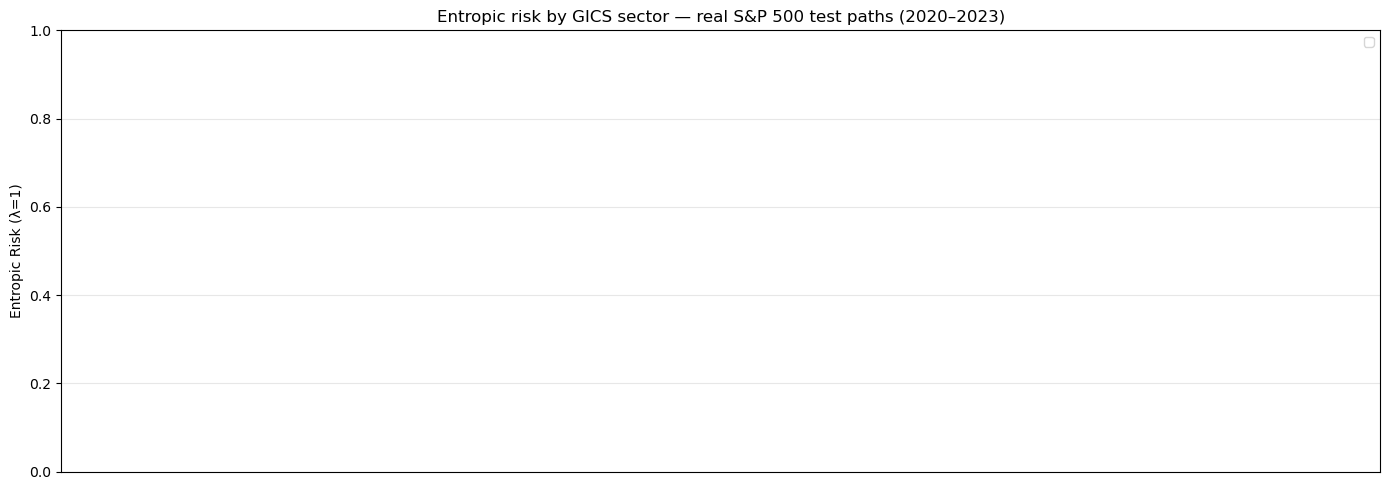

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(sector_df))
w = 0.2
colors = ["gray", "darkorange", "steelblue", "seagreen"]

for i, (col, color) in enumerate(zip(sector_df.columns, colors)):
    ax.bar(x + i * w, sector_df[col].values, width=w, label=col, color=color, alpha=0.8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(sector_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Entropic Risk (λ=1)")
ax.set_title("Entropic risk by GICS sector — real S&P 500 test paths (2020–2023)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sector_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Realised-Volatility Quintile Breakdown

In [13]:
# Realised vol per 30-day window = std of daily log-returns
log_returns = torch.log(S_real[:, 1:] / S_real[:, :-1])   # (M, N)
rv_per_path = log_returns.std(dim=1) * np.sqrt(252)        # annualised

quintile_labels = pd.qcut(rv_per_path.numpy(), q=5, labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"])

rv_results = defaultdict(dict)
for q in quintile_labels.categories:
    mask = torch.tensor(quintile_labels == q)
    for name, errs in methods.items():
        rv_results[str(q)][name] = compute_entropic_risk(errs[mask], lamb=LAMB)

rv_df = pd.DataFrame(rv_results).T
rv_df.index.name = "Vol quintile"
rv_df.round(4)

,BS Delta (analytical),BS Deep Hedger,Clean (GAD),Adversarial (GAD)
Vol quintile,,,,
Q1 (low),0.2446,0.2392,-5.1083,-3.8609
Q2,0.3036,0.2960,-19.5685,-16.9703
Q3,0.3660,0.3583,-20.5100,-14.3264
Q4,0.4602,0.4511,-60.5253,-58.1170
Q5 (high),0.7491,0.7314,-725.4794,-545.3854


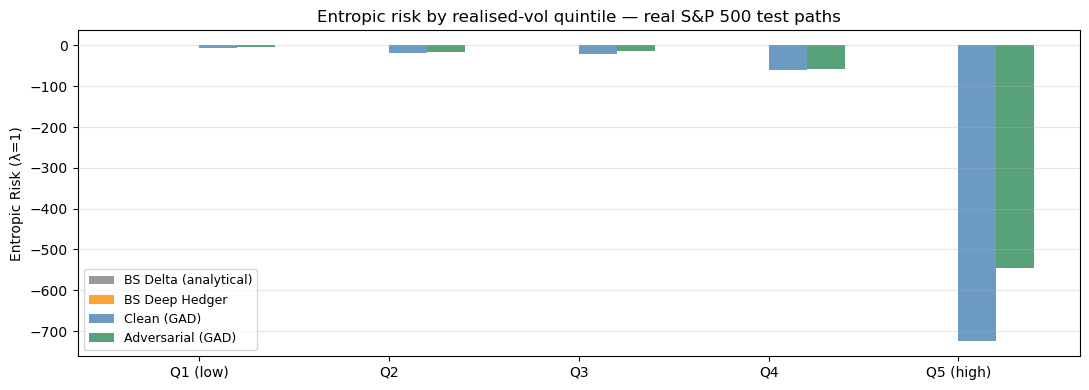

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(rv_df))

for i, (col, color) in enumerate(zip(rv_df.columns, colors)):
    ax.bar(x + i * w, rv_df[col].values, width=w, label=col, color=color, alpha=0.8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(rv_df.index, fontsize=10)
ax.set_ylabel("Entropic Risk (λ=1)")
ax.set_title("Entropic risk by realised-vol quintile — real S&P 500 test paths")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "vol_quintile_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Data Efficiency: Entropic Risk vs. Training Sample Size N

In [15]:
N_SIZES  = [5_000, 10_000, 20_000, 50_000, 100_000]
N_SEEDS  = 3
LAMB     = 1.0

with open(RESULTS_DIR / "best_hps.json") as f:
    best_hps = json.load(f)
best_alpha = best_hps["alpha_bal"]
best_delta = best_hps["delta"]

# Load the full 100k training paths
params_full = GADParams(**{**p_dict, "M": 100_000, "S0": S0, "T": T, "N": N_STEPS})
S_tr_full = GADSimulator(params_full).simulate(seed=19).to(DEVICE)

de_results = {"clean": {}, "adv": {}}

adv_atk = partial(gad_linf_attack, loss_fn=loss_fn, delta=best_delta, iters=5)

for N in N_SIZES:
    risks_clean = []
    risks_adv   = []
    n_seeds_run = min(N_SEEDS, 100_000 // N)

    for s in range(n_seeds_run):
        S_sub = S_tr_full[s * N : (s + 1) * N]

        p0_init_val = float(loss_fn.bs_price(torch.tensor(S0)).item())

        # Clean
        nc, _ = train_adv_gad(
            S_sub, attack_fn=None, loss_fn=loss_fn,
            n_clean=700, n_adv=0, batch_size=min(10_000, N),
            lr=5e-3, alpha_bal=1.0, p0_init=p0_init_val, device=DEVICE,
            desc=f"DE-clean N={N} s{s}",
        )
        errs = compute_errors(nc, S_real, K, DEVICE)
        risks_clean.append(compute_entropic_risk(errs, lamb=LAMB))

        # Adversarial
        na, _ = train_adv_gad(
            S_sub, attack_fn=adv_atk, loss_fn=loss_fn,
            n_clean=300, n_adv=400, batch_size=min(10_000, N),
            lr=5e-3, alpha_bal=best_alpha, p0_init=p0_init_val, device=DEVICE,
            desc=f"DE-adv N={N} s{s}",
        )
        errs = compute_errors(na, S_real, K, DEVICE)
        risks_adv.append(compute_entropic_risk(errs, lamb=LAMB))

    de_results["clean"][N] = risks_clean
    de_results["adv"][N]   = risks_adv
    print(f"N={N:6d}  clean={np.mean(risks_clean):.4f}  adv={np.mean(risks_adv):.4f}  (seeds={n_seeds_run})")

torch.save(de_results, RESULTS_DIR / "data_efficiency_results.pt")

DE-clean N=5000 s0:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

DE-adv N=5000 s0:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for method, color, label in [("clean", "steelblue", "Clean"), ("adv", "seagreen", "Adversarial")]:
    means = [np.mean(de_results[method][N]) for N in N_SIZES]
    mins_ = [np.min(de_results[method][N])  for N in N_SIZES]
    maxs_ = [np.max(de_results[method][N])  for N in N_SIZES]
    ax.plot(N_SIZES, means, marker="o", linewidth=2, color=color, label=label)
    ax.fill_between(N_SIZES, mins_, maxs_, alpha=0.2, color=color)

ax.set_xscale("log")
ax.set_xlabel("Training sample size N", fontsize=12)
ax.set_ylabel("Entropic risk on real S&P 500 paths", fontsize=12)
ax.set_title("Data efficiency — entropic risk vs. N\n(Shaded: min–max range across seeds)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
plt.tight_layout()
plt.savefig(RESULTS_DIR / "data_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Final Summary

In [16]:
print("\n" + "═" * 60)
print("  PRIMARY RESULTS — Real S&P 500 Test Set (2020–2023)")
print("═" * 60)
print(f"  Test paths: {S_real.shape[0]:,}  (rolling 30-day windows)")
print(f"  Unique tickers: {len(set(ticker_labels))}")
print(f"  λ = {LAMB}  (entropic risk-aversion parameter)")
print("─" * 60)
for name, errs in methods.items():
    rho = compute_entropic_risk(errs, lamb=LAMB)
    print(f"  {name:<28s}  ρ = {rho:+.5f}")
print("═" * 60)
print("  (Lower ρ is better. Adversarial < Clean indicates robustness gain.)")


════════════════════════════════════════════════════════════
  PRIMARY RESULTS — Real S&P 500 Test Set (2020–2023)
════════════════════════════════════════════════════════════
  Test paths: 461,513  (rolling 30-day windows)
  Unique tickers: 498
  λ = 1.0  (entropic risk-aversion parameter)
────────────────────────────────────────────────────────────
  BS Delta (analytical)         ρ = +0.40988
  BS Deep Hedger                ρ = +0.40105
  Clean (GAD)                   ρ = -723.87006
  Adversarial (GAD)             ρ = -543.77606
════════════════════════════════════════════════════════════
  (Lower ρ is better. Adversarial < Clean indicates robustness gain.)
